In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(
    str(project_root / "src")
)

In [5]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from atlas.embeddings import (
    EmbeddingModel
)

from atlas.normalization import (
    normalize_concept
)

In [3]:
g_autokaggle = nx.read_graphml(
    "../data/graphs/autokaggle.graphml"
)

g_aide = nx.read_graphml(
    "../data/graphs/aide.graphml"
)

g_data_interpreter = nx.read_graphml(
    "../data/graphs/datainterpreter.graphml"
)

g_ai_scientist = nx.read_graphml(
    "../data/graphs/ai_scientist.graphml"
)

g_swe_agent = nx.read_graphml(
    "../data/graphs/swe_agent.graphml"
)

g_openhands = nx.read_graphml(
    "../data/graphs/openhands.graphml"
)

In [6]:
paper_names = {
    "AutoKaggle",
    "AIDE",
    "Data Interpreter",
    "The AI Scientist",
    "SWE-agent",
    "OpenHands"
}

all_concepts = set()

for graph in [
    g_autokaggle,
    g_aide,
    g_data_interpreter,
    g_ai_scientist,
    g_swe_agent,
    g_openhands
]:

    for node in graph.nodes():

        if node not in paper_names:
            all_concepts.add(normalize_concept(node))

all_concepts = sorted(
    list(all_concepts)
)

print(
    len(all_concepts)
)

42


In [7]:
model = EmbeddingModel()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [8]:
matches = []

for i, concept_a in enumerate(all_concepts):

    for concept_b in all_concepts[i+1:]:

        score = model.similarity(
            concept_a,
            concept_b
        )

        if score >= 0.60:

            matches.append(
                (
                    concept_a,
                    concept_b,
                    score
                )
            )

In [9]:
matches = sorted(
    matches,
    key=lambda x: x[2],
    reverse=True
)

len(matches)

13

In [10]:
matches[:50]

[('frontier large language models',
  'large language models',
  np.float32(0.84802437)),
 ('agent-computer interface', 'multi-agent system', np.float32(0.7247398)),
 ('language model agent', 'large language models', np.float32(0.6817878)),
 ('agent workflow', 'agent-computer interface', np.float32(0.6738309)),
 ('agent-computer interface', 'ai agents', np.float32(0.6695256)),
 ('large language models',
  'transformer-based language modeling',
  np.float32(0.66848755)),
 ('agent workflow', 'multi-agent system', np.float32(0.65281594)),
 ('language model agent',
  'transformer-based language modeling',
  np.float32(0.65182054)),
 ('ai agents', 'multi-agent system', np.float32(0.6514053)),
 ('ai agents', 'machine learning engineering agent', np.float32(0.6449552)),
 ('kaggle competitions', 'kaggle evaluations', np.float32(0.6389116)),
 ('ai agents', 'language model agent', np.float32(0.6194687)),
 ('agent workflow', 'ai agents', np.float32(0.60145175))]

In [11]:
df_matches = pd.DataFrame(
    matches,
    columns=[
        "Concept A",
        "Concept B",
        "Similarity"
    ]
)

df_matches.head(50)

,Concept A,Concept B,Similarity
0,frontier large language models,large language models,0.848024
1,agent-computer interface,multi-agent system,0.724740
2,language model agent,large language models,0.681788
3,agent workflow,agent-computer interface,0.673831
4,agent-computer interface,ai agents,0.669526
5,large language models,transformer-based language modeling,0.668488
6,agent workflow,multi-agent system,0.652816
7,language model agent,transformer-based language modeling,0.651821
8,ai agents,multi-agent system,0.651405
9,ai agents,machine learning engineering agent,0.644955


### Concept Graph

In [22]:
import networkx as nx

concept_graph = nx.Graph()

for concept in all_concepts:
    concept_graph.add_node(concept)

for concept_a, concept_b, score in matches:

    concept_graph.add_edge(
        concept_a,
        concept_b,
        weight=float(score)
    )

print(
    concept_graph.number_of_nodes(),
    concept_graph.number_of_edges()
)

42 13


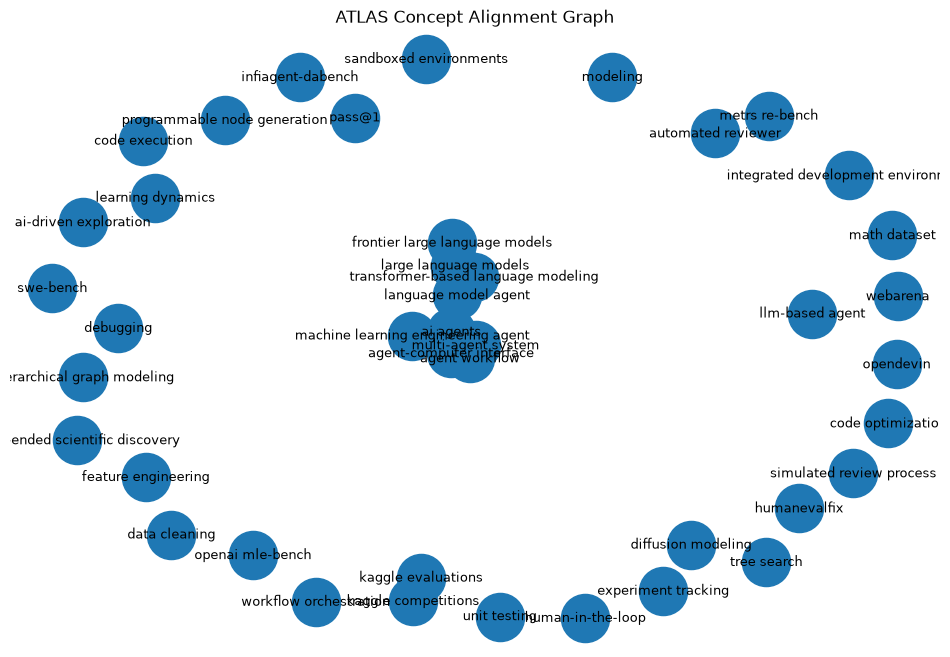

In [23]:
plt.figure(
    figsize=(12, 8)
)

pos = nx.spring_layout(
    concept_graph,
    seed=42
)

nx.draw_networkx_nodes(
    concept_graph,
    pos,
    node_size=1200
)

nx.draw_networkx_edges(
    concept_graph,
    pos
)

nx.draw_networkx_labels(
    concept_graph,
    pos,
    font_size=9
)

plt.title(
    "ATLAS Concept Alignment Graph"
)

plt.axis("off")

plt.show()

In [24]:
components = list(
    nx.connected_components(
        concept_graph
    )
)

len(components)

33

In [25]:
for i, component in enumerate(components):

    print(
        f"\nCluster {i+1}"
    )

    print(
        sorted(component)
    )


Cluster 1
['agent workflow', 'agent-computer interface', 'ai agents', 'frontier large language models', 'language model agent', 'large language models', 'machine learning engineering agent', 'multi-agent system', 'transformer-based language modeling']

Cluster 2
['ai-driven exploration']

Cluster 3
['automated reviewer']

Cluster 4
['code execution']

Cluster 5
['code optimization']

Cluster 6
['data cleaning']

Cluster 7
['debugging']

Cluster 8
['diffusion modeling']

Cluster 9
['experiment tracking']

Cluster 10
['feature engineering']

Cluster 11
['hierarchical graph modeling']

Cluster 12
['human-in-the-loop']

Cluster 13
['humanevalfix']

Cluster 14
['infiagent-dabench']

Cluster 15
['integrated development environment']

Cluster 16
['kaggle competitions', 'kaggle evaluations']

Cluster 17
['learning dynamics']

Cluster 18
['llm-based agent']

Cluster 19
['math dataset']

Cluster 20
['metrs re-bench']

Cluster 21
['modeling']

Cluster 22
['open-ended scientific discovery']

Clus

In [26]:
model.similarity(
    "kaggle competitions",
    "machine learning engineering agent"
)

model.similarity(
    "kaggle competitions",
    "ai agents"
)

model.similarity(
    "kaggle competitions",
    "openai mle-bench"
)

model.similarity(
    "kaggle evaluations",
    "openai mle-bench"
)

np.float32(0.21751988)

In [27]:
concept_graph.number_of_nodes()

42

In [28]:
sorted(nx.isolates(concept_graph))

['ai-driven exploration',
 'automated reviewer',
 'code execution',
 'code optimization',
 'data cleaning',
 'debugging',
 'diffusion modeling',
 'experiment tracking',
 'feature engineering',
 'hierarchical graph modeling',
 'human-in-the-loop',
 'humanevalfix',
 'infiagent-dabench',
 'integrated development environment',
 'learning dynamics',
 'llm-based agent',
 'math dataset',
 'metrs re-bench',
 'modeling',
 'open-ended scientific discovery',
 'openai mle-bench',
 'opendevin',
 'pass@1',
 'programmable node generation',
 'sandboxed environments',
 'simulated review process',
 'swe-bench',
 'tree search',
 'unit testing',
 'webarena',
 'workflow orchestration']